1: What is Boosting in Machine Learning? Explain how it improves weak learners.

Answer:
Boosting is an ensemble learning technique that combines multiple weak learners to create a strong predictive model. A weak learner is a model that performs slightly better than random guessing (e.g., decision stumps).

The key idea behind boosting is sequential learning, where each new model is trained to correct the errors made by the previous models.

How Boosting Works:
Train the first weak model on the dataset.
Identify misclassified instances.
Assign higher weights to misclassified samples.
Train the next model focusing more on these difficult samples.
Repeat the process iteratively.
Combine all models using weighted voting (classification) or averaging (regression).

How it Improves Weak Learners:
Converts weak learners into a strong learner.
Focuses on hard-to-classify data points.
Reduces bias and improves accuracy.
Learns complex patterns through multiple iterations.

Advantages:
High predictive performance
Handles bias effectively
Works well with structured data

Question 2: Difference between AdaBoost and Gradient Boosting
1. Basic Idea
AdaBoost: Focuses on correcting misclassified samples by assigning higher weights
Gradient Boosting: Focuses on minimizing overall error using gradient descent

2. Training Method
AdaBoost: Changes weights of data points after each model
Gradient Boosting: Trains new model on residual errors (previous mistakes)

3. Error Handling
AdaBoost: Misclassified points get more importance
Gradient Boosting: Fits model to reduce residual (difference between actual and predicted)

4. Loss Function
AdaBoost: Uses exponential loss function
Gradient Boosting: Can use any differentiable loss function (MSE, log loss, etc.)

5. Model Combination
AdaBoost: Uses weighted voting of weak learners
Gradient Boosting: Adds models sequentially to minimize loss

6. Complexity
AdaBoost: Simpler and faster
Gradient Boosting: More complex and powerful

7. Overfitting
AdaBoost: Less prone to overfitting
Gradient Boosting: Can overfit if not tuned properly

8. Flexibility
AdaBoost: Limited flexibility
Gradient Boosting: Highly flexible and customizable

9. Performance
AdaBoost: Good for simple problems
Gradient Boosting: Better for complex datasets

10. Example Algorithms
AdaBoost: AdaBoost Classifier
Gradient Boosting: Gradient Boosting, XGBoost, LightGBM, CatBoost

Question 3: How does regularization help in XGBoost?

Regularization in XGBoost helps prevent overfitting and improves generalization by penalizing model complexity.

Types of Regularization in XGBoost:
L1 Regularization (Lasso) – Adds penalty proportional to absolute values of weights
L2 Regularization (Ridge) – Adds penalty proportional to squared weights

How it Helps:
Controls tree complexity
Prevents overly deep trees
Reduces variance
Improves model robustness

Key Parameters:
alpha → L1 regularization
lambda → L2 regularization
max_depth → limits tree depth
Regularization ensures that the model does not memorize training data and performs well on unseen data.

Question 4: Why is CatBoost efficient for categorical data?

CatBoost is specifically designed to handle categorical features efficiently without extensive preprocessing.

Reasons for Efficiency:
Automatic Encoding:
Uses target-based encoding internally
No need for manual one-hot encoding

Ordered Boosting:
Prevents data leakage
Uses permutations for unbiased training

Handles High Cardinality:
Works well with features having many categories

No Need for Scaling:
Works directly with raw categorical values

Advantages:
Faster preprocessing
Better accuracy
Reduced overfitting
Less manual effort

Question 5: Real-world applications of Boosting

Boosting techniques are preferred when high accuracy is required and data is complex.

Applications
Finance:
Credit scoring
Fraud detection

Healthcare:
Disease prediction
Medical diagnosis

E-commerce:
Recommendation systems
Customer churn prediction

Marketing:
Customer segmentation
Campaign optimization

Computer Vision:
Face detection
Object recognition

 Boosting over Bagging:
Better performance on complex patterns
Focuses on difficult cases
Produces more accurate models

In [1]:
#6
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [2]:
#7
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7756446042829698


In [5]:
#8
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize model
model = XGBClassifier(eval_metric='logloss', random_state=42)

# Hyperparameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7]
}

# GridSearch with cross-validation
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train model
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Output
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", accuracy)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best CV Score: 0.9670329670329672
Test Accuracy: 0.956140350877193


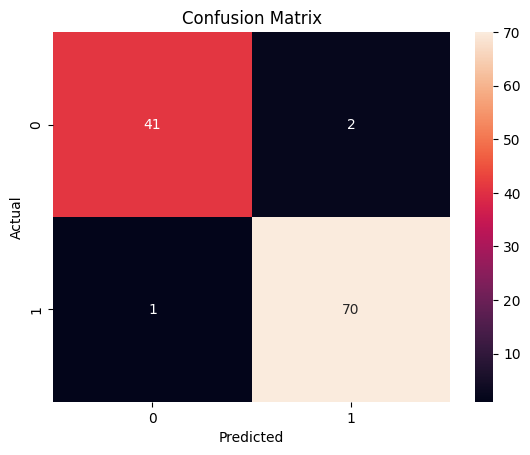

In [7]:
#9
# Install CatBoost (run once)
!pip install catboost

# Import libraries
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

10: FinTech Loan Default Prediction using Boosting

1. Data Preprocessing
Handling raw data properly is very important before applying boosting models.

a) Handling Missing Values:
Numerical features → fill using mean/median
Categorical features → fill using mode or “Unknown” category

b) Handling Categorical Data:
Use CatBoost → handles categorical data automatically
For XGBoost/AdaBoost → use Label Encoding / One-Hot Encoding

c) Feature Scaling:
Not strictly required for tree-based models
Can be skipped for boosting algorithms

2. Handling Imbalanced Dataset
Loan default datasets are usually imbalanced.

Techniques:
Oversampling (SMOTE)
Undersampling
Use class weights
In XGBoost → use scale_pos_weight
Helps model learn minority class (defaulters) better

3. Model Selection (AdaBoost vs XGBoost vs CatBoost)
AdaBoost:
Simple and fast
Less powerful for complex data
XGBoost:
High performance
Good control over parameters
Handles missing values internally
CatBoost (Best Choice):
Handles categorical data automatically
Prevents overfitting
Works well with real-world structured data
 Final Choice: CatBoost or XGBoost

 4. Hyperparameter Tuning Strategy

Use:
GridSearchCV
RandomizedSearchCV

Important parameters:
learning_rate
n_estimators
max_depth
subsample
Helps improve model accuracy and avoid overfitting

 5. Evaluation Metrics (Very Important)

Accuracy alone is not enough for imbalanced data.

Use:
Precision → how many predicted defaults are correct
Recall → how many actual defaults are detected
F1-score → balance of precision & recall
ROC-AUC → best metric for classification
Focus on Recall (to catch defaulters)

In [8]:
#Model training pipeline
# Import libraries
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np

# Example dataset (dummy structure)
# Assume df is your dataset
# df = pd.read_csv("loan_data.csv")

# For demo, create dummy data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model with imbalance handling
model = XGBClassifier(scale_pos_weight=9, eval_metric='logloss')

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       183
           1       0.83      0.88      0.86        17

    accuracy                           0.97       200
   macro avg       0.91      0.93      0.92       200
weighted avg       0.98      0.97      0.98       200

ROC-AUC Score: 0.9633558341369335


7. Business Benefits
Identify high-risk customers
Reduce loan defaults
Improve profit and decision-making
Better credit risk management
Automate loan approval process